# Makemore MLP Part 3 #

## Refactored Code from Part 2 ##

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [3]:
# Read the names from the file
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [4]:
len(words)

32033

In [5]:
# Build character-to-int mappings
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
# Build dataset function to account for data partitioning
block_size = 3 # context length: give last n characters, predict the next one

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size # initial context, [0,0,0,etc] or '...'
    
        for ch in w + '.':
            idx = stoi[ch]
            X.append(context) # Stores context as a training example
            Y.append(idx) # stores correct output of training label
            context = context[1:] + [idx]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)

    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


The next part is to recreate the MLP, but this time there will be less magic numbers.

In [44]:
n_embd = 10 # Embedding dimensionality
n_hidden = 200 # NO. neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/(n_embd * block_size)**0.5 # Scale down to reduce saturation
#b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # Scale down to make logits smaller
b2 = torch.randn(vocab_size, generator=g) * 0

# batchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden)) # For batch norm, allow for unit gaussian at initialization
bnmean_running = torch.zeros((0, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

params = [C, W1, W2, b2, bngain, bnbias]
print(f'Total NO. parameters: {sum(p.nelement() for p in params)}')

for p in params:
    p.requires_grad = True

Total NO. parameters: 12097


In [46]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    idx = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[idx], Ytr[idx]

    # forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) # concat vectors
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation

    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # Batch norm; bnbias makes b1 pointless

    # Keep running count of mean and STD
    # A good way of estimating final mean and STD from batch norm paper
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani # 0.001 is the momentum
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # update via GD
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in params:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 2.1862
  10000/ 200000: 1.9822
  20000/ 200000: 2.3900
  30000/ 200000: 2.1151
  40000/ 200000: 2.1668
  50000/ 200000: 2.0865
  60000/ 200000: 2.2603
  70000/ 200000: 2.3095
  80000/ 200000: 2.1861
  90000/ 200000: 1.9258
 100000/ 200000: 2.1005
 110000/ 200000: 2.3668
 120000/ 200000: 1.9790
 130000/ 200000: 1.6971
 140000/ 200000: 1.9422
 150000/ 200000: 2.0211
 160000/ 200000: 1.8602
 170000/ 200000: 1.7841
 180000/ 200000: 1.9956
 190000/ 200000: 2.1478


Ideally, the distribution should be uniform at the start, but we have a high loss initially, so the initialization is incorrect. A uniform distribution gives an initial loss of around 3.3.

Another problem is that tanh squashes many of the hidden layer values to -1 and 1. I.e., the tanh is very active. Because of this, the gradients will basically be destroyed by the flat tails.

Can consider other activations, but they can have the same problems. In ReLU, for example, any negative value will set the gradient to 0, giving us a dead neuron. Leaky ReLU fixes this.

We want the weights to follow a standard normal distribution. Therefore we multiply our standard deviation by (gain) / (fan_in)

We can also just normalize the hidden pre-activation values - this is batch normalization.

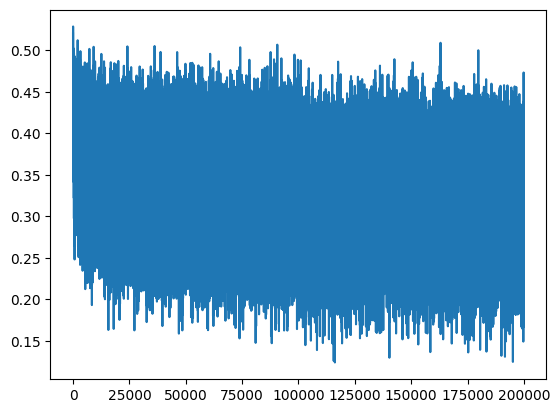

In [32]:
plt.plot(lossi)

In [38]:
@torch.no_grad() # disables gradient tracking here
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1 
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y) 
    
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0668270587921143
val 2.1049270629882812


In [13]:
# Sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(15):
    out = []
    context = [0] * block_size

    while True:
        # forward pass
        emb = C[torch.tensor([context])] 
        h = torch.tanh(emb.view(1, -1) @ W1 + b1) 
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # Take sample
        idx = torch.multinomial(probs, num_samples=1, generator=g).item()

        # Shift context window
        context = context[1:] + [idx]
        out.append(idx)
        
        # Check for special '.' token
        if idx == 0:
            break

    print(''.join(itos[i] for i in out)) # print gen'd word

carpah.
amorie.
khirmy.
xhetty.
salayson.
mahnen.
den.
art.
kaqui.
nellara.
chaiir.
kaleigh.
ham.
jorn.
quintis.
